# GBDA 对抗攻击 — 基于梯度的分布攻击

## 概述

本 Notebook 实现对**连续文本空间**的 **GBDA (Gradient-based Distributional Attack)** 对抗攻击。

### GCG vs GBDA
| 方法 | 优化方式 | 搜索空间 | 效率 |
|------|---------|---------|------|
| GCG | 离散坐标贪心搜索 | 离散 token 替换 | 每步需评估多个候选 |
| **GBDA** | **连续梯度下降** | **Gumbel-Softmax 连续松弛** | **标准反向传播，更高效** |

### GBDA 原理
1. 对每个 token 位置维护一个**连续参数向量** $\theta_i \in \mathbb{R}^{V}$（$V$ = 词汇表大小）
2. 使用 **Gumbel-Softmax** 技巧实现可微分的离散采样
3. 通过**梯度下降**优化 $\theta$，最小化分类损失 + **负对数似然正则项**
4. **温度退火**使采样逐渐从软分布变为离散 token

### 流程
1. 在 **AG News** 数据集上训练一个文本 Transformer 分类器（4 类新闻主题）
2. 实现 GBDA 攻击：在连续松弛空间中优化对抗分布
3. 可视化攻击效果

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import math
import random
import numpy as np
from collections import Counter
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd

plt.rcParams['axes.unicode_minus'] = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


## 1. 数据加载与预处理

从本地 CSV 文件加载 AG News 数据集。

In [2]:
# 从本地 CSV 文件加载 AG News 数据集
TRAIN_PATH = 'data/ag_news_csv/train.csv'
TEST_PATH = 'data/ag_news_csv/test.csv'

LABEL_NAMES = ['World', 'Sports', 'Business', 'Sci/Tech']
NUM_CLASSES = 4

# 读取 CSV 文件
train_df = pd.read_csv(TRAIN_PATH, header=None, names=['class', 'title', 'description'])
test_df = pd.read_csv(TEST_PATH, header=None, names=['class', 'title', 'description'])

print(f'训练集: {len(train_df)} 条')
print(f'测试集: {len(test_df)} 条')

# 合并标题和描述作为文本
train_df['text'] = train_df['title'] + ' ' + train_df['description']
test_df['text'] = test_df['title'] + ' ' + test_df['description']

# 标签从 1-4 转为 0-3
train_df['label'] = train_df['class'] - 1
test_df['label'] = test_df['class'] - 1

# 转换为统一格式列表
dataset = {
    'train': [{'label': row['label'], 'text': row['text']} for _, row in train_df.iterrows()],
    'test': [{'label': row['label'], 'text': row['text']} for _, row in test_df.iterrows()]
}

print(f'样本示例:')
print(f'  标签: {LABEL_NAMES[dataset["train"][0]["label"]]}')
print(f'  文本: {dataset["train"][0]["text"][:150]}...')

训练集: 120000 条
测试集: 7600 条
样本示例:
  标签: Business
  文本: Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again....


In [3]:
# SimpleTokenizer 类定义
class SimpleTokenizer:
    """简单的词级别 tokenizer，构建词汇表"""
    
    def __init__(self, min_freq=2, max_vocab_size=15000, max_seq_len=64):
        self.min_freq = min_freq
        self.max_vocab_size = max_vocab_size
        self.max_seq_len = max_seq_len
        self.word2idx = {}
        self.idx2word = {}
        # 特殊 token
        self.PAD_IDX = 0
        self.UNK_IDX = 1
        self.CLS_IDX = 2
        self.special_tokens = ['<PAD>', '<UNK>', '<CLS>']
    
    def build_vocab(self, texts):
        counter = Counter()
        for text in texts:
            words = self._tokenize(text)
            counter.update(words)
        
        vocab = self.special_tokens.copy()
        for word, freq in counter.most_common(self.max_vocab_size - len(self.special_tokens)):
            if freq >= self.min_freq:
                vocab.append(word)
        
        self.word2idx = {w: i for i, w in enumerate(vocab)}
        self.idx2word = {i: w for i, w in enumerate(vocab)}
        print(f'词汇表大小: {len(self.word2idx)}')
    
    def _tokenize(self, text):
        if text is None:
            return []
        text = str(text).lower().strip()
        import re
        words = re.findall(r'[a-z0-9]+', text)
        return words
    
    def encode(self, text):
        words = self._tokenize(text)
        ids = [self.CLS_IDX]
        for w in words[:self.max_seq_len - 1]:
            ids.append(self.word2idx.get(w, self.UNK_IDX))
        ids = ids[:self.max_seq_len]
        return ids if ids else [self.CLS_IDX]
    
    def decode(self, ids):
        return ' '.join(self.idx2word.get(i, '<UNK>') for i in ids if i != self.PAD_IDX)
    
    @property
    def vocab_size(self):
        return len(self.word2idx)

In [4]:
# 构建词汇表（使用训练集文本）
tokenizer = SimpleTokenizer(min_freq=2, max_vocab_size=15000, max_seq_len=64)

train_texts = [item['text'] for item in dataset['train']]
tokenizer.build_vocab(train_texts)

# 查看编码示例
sample = dataset['train'][0]['text']
encoded = tokenizer.encode(sample)
print(f'原文: {sample[:100]}...')
print(f'编码: {encoded[:20]}...')
print(f'解码: {tokenizer.decode(encoded)}')

词汇表大小: 15000
原文: Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\b...
编码: [2, 452, 453, 1649, 14339, 111, 66, 3, 853, 23, 23, 759, 8120, 452, 389, 9, 10128, 2896, 6, 5770]...
解码: <CLS> wall st bears claw back into the black reuters reuters short sellers wall street s dwindling band of ultra <UNK> are seeing green again


## 2. 文本 Transformer 模型定义

In [6]:
class TokenEmbedding(nn.Module):
    """Token 嵌入 + 位置编码"""
    def __init__(self, vocab_size, embed_dim, max_len=512, dropout=0.1):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_emb = nn.Embedding(max_len, embed_dim)
        self.dropout = nn.Dropout(dropout)
        self.embed_scale = math.sqrt(embed_dim)
    
    def forward(self, x):
        seq_len = x.size(1)
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0)
        x = self.token_emb(x) * self.embed_scale + self.pos_emb(positions)
        return self.dropout(x)


class TextTransformerBlock(nn.Module):
    """Transformer 编码器块"""
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, embed_dim),
            nn.Dropout(dropout),
        )
    
    def forward(self, x, padding_mask=None):
        normed = self.norm1(x)
        attn_out, _ = self.attn(normed, normed, normed, key_padding_mask=padding_mask)
        x = x + attn_out
        x = x + self.ff(self.norm2(x))
        return x


class TextTransformer(nn.Module):
    """文本 Transformer 分类器"""
    def __init__(self, vocab_size, num_classes, embed_dim=128, num_heads=4,
                 ff_dim=512, num_layers=4, max_len=512, dropout=0.1):
        super().__init__()
        self.embedding = TokenEmbedding(vocab_size, embed_dim, max_len, dropout)
        self.blocks = nn.ModuleList([
            TextTransformerBlock(embed_dim, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.classifier = nn.Linear(embed_dim, num_classes)
    
    def forward(self, x):
        # x: (batch, seq_len) of token ids
        padding_mask = (x == 0)
        x = self.embedding(x)
        for block in self.blocks:
            x = block(x, padding_mask=padding_mask)
        x = self.norm(x)
        cls_output = x[:, 0, :]
        return self.classifier(cls_output)
    
    def get_embeddings(self, x):
        """获取嵌入表示"""
        padding_mask = (x == 0)
        x_emb = self.embedding.token_emb(x) * self.embedding.embed_scale
        x_emb = x_emb + self.embedding.pos_emb(
            torch.arange(x.size(1), device=x.device).unsqueeze(0)
        )
        return x_emb, padding_mask
    
    def forward_from_embeddings(self, x_emb, padding_mask=None):
        """从嵌入层之后前向传播"""
        x = self.embedding.dropout(x_emb)
        for block in self.blocks:
            x = block(x, padding_mask=padding_mask)
        x = self.norm(x)
        cls_output = x[:, 0, :]
        return self.classifier(cls_output)

In [7]:
class AGNewsDataset(Dataset):
    def __init__(self, data_source, tokenizer, max_samples=None):
        self.data = []
        limit = min(max_samples, len(data_source)) if max_samples else len(data_source)
        
        for idx in tqdm(range(limit), desc='编码数据'):
            item = data_source[idx]
            text = item['text']
            label = item['label']
            ids = tokenizer.encode(text)
            self.data.append((ids, label))
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        ids, label = self.data[idx]
        return torch.tensor(ids, dtype=torch.long), label


def collate_fn(batch, pad_idx=0):
    texts, labels = zip(*batch)
    max_len = max(len(t) for t in texts)
    padded = torch.full((len(texts), max_len), pad_idx, dtype=torch.long)
    for i, t in enumerate(texts):
        padded[i, :len(t)] = t
    labels = torch.tensor(labels, dtype=torch.long)
    return padded, labels


# 为加速演示，取子集训练
TRAIN_SUBSET = 30000
TEST_SUBSET = 5000

train_src = dataset['train'][:TRAIN_SUBSET]
test_src = dataset['test'][:TEST_SUBSET]

train_ds = AGNewsDataset(train_src, tokenizer)
test_ds = AGNewsDataset(test_src, tokenizer)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, collate_fn=lambda b: collate_fn(b, tokenizer.PAD_IDX), num_workers=0)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, collate_fn=lambda b: collate_fn(b, tokenizer.PAD_IDX), num_workers=0)

print(f'训练集: {len(train_ds)} 条 | 测试集: {len(test_ds)} 条')

编码数据: 100%|██████████| 5000/5000 [00:00<00:00, 51263.83it/s]

训练集: 30000 条 | 测试集: 5000 条


In [8]:
model = TextTransformer(
    vocab_size=tokenizer.vocab_size,
    num_classes=NUM_CLASSES,
    embed_dim=128,
    num_heads=4,
    ff_dim=512,
    num_layers=4,
    max_len=64,
    dropout=0.1
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'模型参数量: {total_params:,}')
print(model)

模型参数量: 2,722,052
TextTransformer(
  (embedding): TokenEmbedding(
    (token_emb): Embedding(15000, 128, padding_idx=0)
    (pos_emb): Embedding(64, 128)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (blocks): ModuleList(
    (0-3): 4 x TextTransformerBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
      )
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (ff): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=512, out_features=128, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
  (classifier): Linear(in_features=128, out_features=4, bias=Tru

## 3. 训练模型

In [9]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    pbar = tqdm(loader, desc='Training')
    for texts, labels in pbar:
        texts, labels = texts.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(texts)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, pred = outputs.max(1)
        total += labels.size(0)
        correct += pred.eq(labels).sum().item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100.*correct/total:.2f}%'})
    return total_loss / len(loader), 100. * correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for texts, labels in tqdm(loader, desc='Evaluating'):
            texts, labels = texts.to(device), labels.to(device)
            outputs = model(texts)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, pred = outputs.max(1)
            total += labels.size(0)
            correct += pred.eq(labels).sum().item()
    return total_loss / len(loader), 100. * correct / total

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

NUM_EPOCHS = 10
best_acc = 0

for epoch in range(1, NUM_EPOCHS + 1):
    print(f'\nEpoch {epoch}/{NUM_EPOCHS}')
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    scheduler.step()
    print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%')
    print(f'Test  Loss: {test_loss:.4f} | Test  Acc: {test_acc:.2f}%')
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), 'best_text_transformer_agnews.pth')
        print(f'保存最佳模型 (Acc: {best_acc:.2f}%)')

print(f'\n最佳测试准确率: {best_acc:.2f}%')


Epoch 1/10


Evaluating: 100%|██████████| 20/20 [00:02<00:00,  9.77it/s]


Train Loss: 0.7398 | Train Acc: 70.41%
Test  Loss: 0.4936 | Test  Acc: 82.82%
保存最佳模型 (Acc: 82.82%)

Epoch 2/10


Evaluating: 100%|██████████| 20/20 [00:01<00:00, 10.92it/s]


Train Loss: 0.4176 | Train Acc: 85.33%
Test  Loss: 0.4329 | Test  Acc: 84.82%
保存最佳模型 (Acc: 84.82%)

Epoch 3/10


...

Train Loss: 0.1747 | Train Acc: 93.95%
Test  Loss: 0.4219 | Test  Acc: 87.26%

Epoch 9/10


Evaluating: 100%|██████████| 20/20 [00:01<00:00, 11.95it/s]


Train Loss: 0.1590 | Train Acc: 94.39%
Test  Loss: 0.4358 | Test  Acc: 87.58%
保存最佳模型 (Acc: 87.58%)

Epoch 10/10


Evaluating: 100%|██████████| 20/20 [00:01<00:00, 11.54it/s]

Train Loss: 0.1541 | Train Acc: 94.71%
Test  Loss: 0.4381 | Test  Acc: 87.54%

最佳测试准确率: 87.58%


In [11]:
# 加载最佳模型
model.load_state_dict(torch.load('best_text_transformer_agnews.pth', weights_only=True))
model.eval()
print('已加载最佳模型')

已加载最佳模型


## 4. GBDA 对抗攻击

### 攻击原理

GBDA (Gradient-based Distributional Attack) 的核心思想：

不同于 GCG 的离散搜索，GBDA 在**连续空间**中优化对抗样本：

1. **Gumbel-Softmax 松弛**：每个 token 位置 $i$ 的参数 $\theta_i \in \mathbb{R}^V$ 通过 Gumbel-Softmax 转换为可微分的概率分布
2. **连续优化**：使用标准梯度下降（Adam）优化 $\theta$，而非离散搜索
3. **正则化项**：$\lambda \cdot (-\log P_\theta(y_{\text{orig}}))$ 控制扰动强度，保持语义相似
   - 注：不能用 $\text{KL}(P_\theta \parallel \text{one-hot})$，因为 one-hot 的 $\log(0)=-\infty$ 会导致 NaN
4. **温度退火**：温度 $\tau$ 从高到低递减，使分布逐渐"硬化"为离散 token

### 损失函数（非定向攻击）

$$
\mathcal{L} = -\text{CE}(f(\text{GumbelSoftmax}_\tau(\theta) \cdot E), \, y_{\text{true}}) - \lambda \cdot \log P_\theta(y_{\text{orig}})
$$

其中 $E$ 是嵌入矩阵，$P_\theta = \text{Softmax}(\theta/\tau)$，$y_{\text{orig}}$ 是原始 token 序列。

In [15]:
class GBDAttack:
    """
    GBDA (Gradient-based Distributional Attack)
    
    基于 Gumbel-Softmax 连续松弛的文本对抗攻击。
    通过梯度下降优化每个 token 位置上的概率分布参数 θ，
    使模型分类出错，同时用正则化保持文本语义相似。
    """
    
    def __init__(self, model, tokenizer, lr=0.5, max_steps=200,
                 reg_lambda=0.01, init_temp=2.0, min_temp=0.1, targeted=False):
        """
        Args:
            model: TextTransformer 模型
            tokenizer: SimpleTokenizer
            lr: Adam 学习率
            max_steps: 最大优化步数
            reg_lambda: 正则化系数（越大则对抗文本越接近原文）
            init_temp: Gumbel-Softmax 初始温度
            min_temp: 最低温度（退火终点）
            targeted: 是否为定向攻击
        """
        self.model = model
        self.tokenizer = tokenizer
        self.lr = lr
        self.max_steps = max_steps
        self.reg_lambda = reg_lambda
        self.init_temp = init_temp
        self.min_temp = min_temp
        self.targeted = targeted
    
    def _get_temperature(self, step):
        """温度退火调度：从初始温度指数衰减到最低温度"""
        decay_rate = (self.min_temp / self.init_temp) ** (1.0 / self.max_steps)
        return max(self.min_temp, self.init_temp * (decay_rate ** step))
    
    def _regularization_loss(self, adv_dist, orig_ids):
        """
        正则化损失：原始 token 在对抗分布下的负对数似然（交叉熵）
        
        这比 KL(adv || one_hot) 更稳定，因为 one_hot 的 log(0) = -inf 会导致 NaN。
        
        adv_dist: (seq_len, vocab_size) - 对抗分布 P_θ = Softmax(θ/τ)
        orig_ids: (seq_len,) - 原始 token ID
        """
        seq_len = orig_ids.size(0)
        # 取每个位置上原始 token 对应的概率
        orig_token_probs = adv_dist[torch.arange(seq_len, device=orig_ids.device), orig_ids]
        # 避免 log(0)
        orig_token_probs = orig_token_probs.clamp(min=1e-10)
        # 负对数似然：-log(P_θ(y_orig))
        nll = -orig_token_probs.log()
        # 对 PAD 位置做掩码（PAD_IDX=0）
        mask = (orig_ids != self.tokenizer.PAD_IDX).float()
        return (nll * mask).sum() / mask.sum().clamp(min=1)
    
    def attack(self, text, true_label, target_label=None):
        """
        对单条文本执行 GBDA 攻击。
        
        Args:
            text: 原始文本
            true_label: 正确标签
            target_label: 目标标签（定向攻击时使用）
        
        Returns:
            dict: 攻击结果
        """
        # 编码
        input_ids = torch.tensor(
            self.tokenizer.encode(text), dtype=torch.long
        ).unsqueeze(0).to(device)
        original_ids = input_ids.clone()
        
        seq_len = input_ids.size(1)
        vocab_size = self.tokenizer.vocab_size
        
        # 确认模型预测正确
        with torch.no_grad():
            orig_logits = self.model(input_ids)
            orig_pred = orig_logits.argmax(dim=1).item()
        
        if orig_pred != true_label:
            return {'success': False, 'reason': '模型预测已错误'}
        
        attack_label = target_label if (self.targeted and target_label is not None) else true_label
        
        # 初始化扰动参数 θ（在 logit 空间）
        # 用原始 token 附近的小噪声初始化，加速收敛
        theta = torch.zeros(1, seq_len, vocab_size, device=device)
        for i in range(seq_len):
            tid = input_ids[0, i].item()
            if tid != self.tokenizer.PAD_IDX:
                theta[0, i, tid] = 5.0  # 让初始分布集中在原始 token 上
        # 添加少量随机噪声打破对称性
        theta = theta + torch.randn_like(theta) * 0.01
        theta.requires_grad_(True)
        
        optimizer = torch.optim.Adam([theta], lr=self.lr)
        
        attack_label_tensor = torch.tensor([attack_label], device=device)
        orig_ids_flat = input_ids.squeeze(0)  # (seq_len,) 用于正则化
        
        best_theta = theta.detach().clone()
        best_loss = float('inf')
        
        # 记录轨迹
        trace = {'step': [], 'cls_loss': [], 'reg_loss': [], 'total_loss': [], 'pred': []}
        
        pbar = tqdm(range(self.max_steps), desc='GBDA Attack', leave=False)
        
        for step in pbar:
            temp = self._get_temperature(step)
            optimizer.zero_grad()
            
            # --- Gumbel-Softmax 采样 ---
            # 使用 Gumbel-Softmax 得到可微分的"软"离散样本
            adv_sample = F.gumbel_softmax(theta, tau=temp, hard=False, dim=-1)  # (1, seq_len, vocab_size)
            
            # 通过嵌入层得到连续表示
            adv_emb = adv_sample @ self.model.embedding.token_emb.weight  # (1, seq_len, embed_dim)
            adv_emb = adv_emb * self.model.embedding.embed_scale
            
            # 添加位置编码
            positions = torch.arange(seq_len, device=device).unsqueeze(0)
            adv_emb = adv_emb + self.model.embedding.pos_emb(positions)
            
            # 前向传播
            padding_mask = (input_ids == 0)
            logits = self.model.forward_from_embeddings(adv_emb, padding_mask=padding_mask)
            
            # --- 分类损失 ---
            if self.targeted:
                cls_loss = F.cross_entropy(logits, attack_label_tensor)
            else:
                # 非定向：最大化真实标签的损失 = 最小化负交叉熵
                cls_loss = -F.cross_entropy(logits, attack_label_tensor)
            
            # --- 正则化损失（负对数似然）---
            # 对抗分布 P_θ = Softmax(θ/τ)
            adv_dist = F.softmax(theta / temp, dim=-1).squeeze(0)  # (seq_len, vocab_size)
            reg_loss = self._regularization_loss(adv_dist, orig_ids_flat)
            
            # --- 总损失 ---
            loss = cls_loss + self.reg_lambda * reg_loss
            
            loss.backward()
            optimizer.step()
            
            # 追踪最佳 θ
            if loss.item() < best_loss:
                best_loss = loss.item()
                best_theta = theta.detach().clone()
            
            # --- 评估当前攻击效果 ---
            with torch.no_grad():
                # 直接用 argmax 得到离散 token（比 Gumbel-Softmax hard 更稳定）
                hard_ids = theta.argmax(dim=-1)  # (1, seq_len)
                hard_logits = self.model(hard_ids)
                pred = hard_logits.argmax(dim=1).item()
            
            if self.targeted:
                success = (pred == target_label)
            else:
                success = (pred != true_label)
            
            # 记录轨迹
            trace['step'].append(step)
            trace['cls_loss'].append(cls_loss.item())
            trace['reg_loss'].append(reg_loss.item())
            trace['total_loss'].append(loss.item())
            trace['pred'].append(pred)
            
            pbar.set_postfix({
                'temp': f'{temp:.3f}',
                'cls': f'{cls_loss.item():.3f}',
                'reg': f'{reg_loss.item():.3f}',
                'pred': f'{LABEL_NAMES[pred]}',
                'success': '✓' if success else '✗'
            })
            
            if success:
                # 攻击成功
                with torch.no_grad():
                    final_temp = self._get_temperature(self.max_steps - 1)
                    final_dist = F.softmax(best_theta / final_temp, dim=-1)
                    final_ids = final_dist.argmax(dim=-1)
                    
                    final_logits = self.model(final_ids)
                    final_pred = final_logits.argmax(dim=1).item()
                    final_conf = F.softmax(final_logits, dim=1).max().item()
                    orig_conf = F.softmax(orig_logits, dim=1).max().item()
                
                return {
                    'success': True,
                    'steps': step + 1,
                    'original_ids': original_ids.squeeze(0).cpu(),
                    'adversarial_ids': final_ids.squeeze(0).cpu(),
                    'original_pred': orig_pred,
                    'adversarial_pred': final_pred,
                    'original_text': text,
                    'adversarial_text': self.tokenizer.decode(final_ids.squeeze(0).cpu().tolist()),
                    'true_label': true_label,
                    'orig_confidence': orig_conf,
                    'adv_confidence': final_conf,
                    'final_loss': best_loss,
                    'trace': trace,
                }
        
        # 达到最大步数仍未成功
        with torch.no_grad():
            final_temp = self._get_temperature(self.max_steps - 1)
            final_dist = F.softmax(best_theta / final_temp, dim=-1)
            final_ids = final_dist.argmax(dim=-1)
            
            final_logits = self.model(final_ids)
            final_pred = final_logits.argmax(dim=1).item()
            final_conf = F.softmax(final_logits, dim=1).max().item()
            orig_conf = F.softmax(orig_logits, dim=1).max().item()
        
        return {
            'success': False,
            'steps': self.max_steps,
            'reason': '达到最大步数',
            'original_ids': original_ids.squeeze(0).cpu(),
            'adversarial_ids': final_ids.squeeze(0).cpu(),
            'original_pred': orig_pred,
            'adversarial_pred': final_pred,
            'original_text': text,
            'adversarial_text': self.tokenizer.decode(final_ids.squeeze(0).cpu().tolist()),
            'true_label': true_label,
            'orig_confidence': orig_conf,
            'adv_confidence': final_conf,
            'final_loss': best_loss,
            'trace': trace,
        }

## 5. 准备攻击样本

In [16]:
# 找一批正确分类的测试样本
model.eval()
correct_samples = []

with torch.no_grad():
    for idx in tqdm(range(min(2000, len(test_ds))), desc='寻找正确分类样本'):
        ids, label = test_ds[idx]
        ids_input = ids.unsqueeze(0).to(device)
        logits = model(ids_input)
        pred = logits.argmax(dim=1).item()
        if pred == label:
            raw_text = test_src[idx]['text']
            correct_samples.append({
                'idx': idx,
                'text': raw_text,
                'label': label,
                'ids': ids,
                'confidence': F.softmax(logits, dim=1).max().item()
            })
            if len(correct_samples) >= 50:
                break

print(f'找到 {len(correct_samples)} 个正确分类的样本')
for s in correct_samples[:3]:
    print(f'  [{LABEL_NAMES[s["label"]]}] (conf={s["confidence"]:.3f}) {s["text"][:80]}...')

寻找正确分类样本:   3%|▎         | 57/2000 [00:00<00:12, 155.60it/s]

找到 50 个正确分类的样本
  [Business] (conf=0.971) Fears for T N pension after talks Unions representing workers at Turner   Newall...
  [Sci/Tech] (conf=0.996) The Race is On: Second Private Team Sets Launch Date for Human Spaceflight (SPAC...
  [Sci/Tech] (conf=0.997) Ky. Company Wins Grant to Study Peptides (AP) AP - A company founded by a chemis...


## 6. 运行 GBDA 攻击实验

In [17]:
# 初始化 GBDA 攻击器
attacker = GBDAttack(
    model=model,
    tokenizer=tokenizer,
    lr=0.5,               # Adam 学习率
    max_steps=200,         # 最大优化步数（稍微增加）
    reg_lambda=0.005,      # 正则化系数（越小攻击越激进，但文本变化越大）
    init_temp=2.0,         # Gumbel-Softmax 初始温度
    min_temp=0.1,          # 最小温度
    targeted=False         # 非定向攻击
)

# 攻击实验
NUM_ATTACK = 20
results = []

print(f'开始 GBDA 攻击 ({NUM_ATTACK} 个样本)...')
print('=' * 70)

for i, sample in enumerate(correct_samples[:NUM_ATTACK]):
    print(f'\n[{i+1}/{NUM_ATTACK}] 攻击样本 (标签: {LABEL_NAMES[sample["label"]]})')
    print(f'  原文: {sample["text"][:100]}...')
    
    result = attacker.attack(sample['text'], sample['label'])
    results.append(result)
    
    if result['success']:
        print(f'  ✓ 攻击成功! 步数: {result["steps"]}')
        print(f'    原始预测: {LABEL_NAMES[result["original_pred"]]} (conf={result["orig_confidence"]:.3f})')
        print(f'    对抗预测: {LABEL_NAMES[result["adversarial_pred"]]} (conf={result["adv_confidence"]:.3f})')
        print(f'    对抗文本: {result["adversarial_text"][:100]}...')
    else:
        print(f'  ✗ 攻击失败: {result.get("reason", "未知")}')

开始 GBDA 攻击 (20 个样本)...

[1/20] 攻击样本 (标签: Business)
  原文: Fears for T N pension after talks Unions representing workers at Turner   Newall say they are 'disap...


GBDA Attack:   0%|          | 0/200 [00:00<?, ?it/s]

  ✓ 攻击成功! 步数: 8
    原始预测: Business (conf=0.971)
    对抗预测: World (conf=0.785)
    对抗文本: survive fears for t n pension after songs unions representing workers at turner <UNK> say they are d...

[2/20] 攻击样本 (标签: Sci/Tech)
  原文: The Race is On: Second Private Team Sets Launch Date for Human Spaceflight (SPACE.com) SPACE.com - T...


  ✓ 攻击成功! 步数: 17
    原始预测: Sci/Tech (conf=0.996)
    对抗预测: Business (conf=0.519)
    对抗文本: causing salaries race is on second private team tailored launch date for defectors pulitzer gangs di...

[3/20] 攻击样本 (标签: Sci/Tech)
  原文: Ky. Company Wins Grant to Study Peptides (AP) AP - A company founded by a chemistry researcher at th...


  ✓ 攻击成功! 步数: 16
    原始预测: Sci/Tech (conf=0.997)
    对抗预测: Sports (conf=0.557)
    对抗文本: middleweight andrea prove wins grant to study carrier ap ap a company founded by mohamed ghraib rese...

[4/20] 攻击样本 (标签: Sci/Tech)
  原文: Open Letter Against British Copyright Indoctrination in Schools The British Department for Education...


...

  ✓ 攻击成功! 步数: 7
    原始预测: Sci/Tech (conf=0.894)
    对抗预测: Sci/Tech (conf=0.894)
    对抗文本: <CLS> <UNK> the <UNK> of life when did life begin one <UNK> clue <UNK> from the fossil records in we...

[17/20] 攻击样本 (标签: Sci/Tech)
  原文: Storage, servers bruise HP earnings update Earnings per share rise compared with a year ago, but com...


  ✓ 攻击成功! 步数: 9
    原始预测: Sci/Tech (conf=0.964)
    对抗预测: Sports (conf=0.957)
    对抗文本: diet suburban servers <UNK> hp earnings update earnings mysteries dismal rise nixon with a year schw...

[18/20] 攻击样本 (标签: Sci/Tech)
  原文: Sun's Looking Glass Provides 3D View Developers get early code for new operating system 'skin' still...


  ✓ 攻击成功! 步数: 7
    原始预测: Sci/Tech (conf=0.978)
    对抗预测: World (conf=0.849)
    对抗文本: <CLS> sun s looking glass awake 3d view developers sakhnin early kickbacks for lebanese operating tr...

[19/20] 攻击样本 (标签: Sci/Tech)
  原文: IBM Chips May Someday Heal Themselves New technology applies electrical fuses to help identify and r...


  ✓ 攻击成功! 步数: 7
    原始预测: Sci/Tech (conf=0.952)
    对抗预测: World (conf=0.681)
    对抗文本: <CLS> lagerfeld chips may someday heal tests xiaoping technology applies electrical <UNK> to cnn tur...

[20/20] 攻击样本 (标签: Sci/Tech)
  原文: News: Sluggish movement on power grid cyber security Industry cyber security standards fail to reach...


  ✓ 攻击成功! 步数: 11
    原始预测: Sci/Tech (conf=0.997)
    对抗预测: Business (conf=0.581)
    对抗文本: berkshire news sluggish petter on noah grid induce security industry columnist security standards 17...


## 7. 攻击结果统计

In [18]:
# 统计结果
if len(results) == 0:
    print('没有攻击结果，请先运行攻击代码！')
else:
    success_results = [r for r in results if r['success']]
    fail_results = [r for r in results if not r['success']]

    total = len(results)
    success_count = len(success_results)
    success_rate = 100. * success_count / total if total > 0 else 0
    avg_steps = np.mean([r['steps'] for r in success_results]) if success_results else 0

    # 计算修改 token 数量
    token_changes = []
    for r in success_results:
        orig = r['original_ids'].tolist()
        adv = r['adversarial_ids'].tolist()
        changes = sum(1 for a, b in zip(orig, adv) if a != b)
        total_tokens = len(orig)
        token_changes.append(changes)

    avg_changes = np.mean(token_changes) if token_changes else 0

    print('=' * 60)
    print('         GBDA 攻击结果统计')
    print('=' * 60)
    print(f'  总攻击样本数:     {total}')
    print(f'  成功数:           {success_count}')
    print(f'  攻击成功率:       {success_rate:.1f}%')
    print(f'  平均成功步数:     {avg_steps:.1f}')
    print(f'  平均修改 token 数: {avg_changes:.1f}')
    print(f'  模型原始准确率:   100% (仅选正确分类样本)')
    print(f'  攻击后准确率:     {100. * (total - success_count) / total:.1f}%')
    print('=' * 60)

         GBDA 攻击结果统计
  总攻击样本数:     20
  成功数:           20
  攻击成功率:       100.0%
  平均成功步数:     11.4
  平均修改 token 数: 13.9
  模型原始准确率:   100% (仅选正确分类样本)
  攻击后准确率:     0.0%


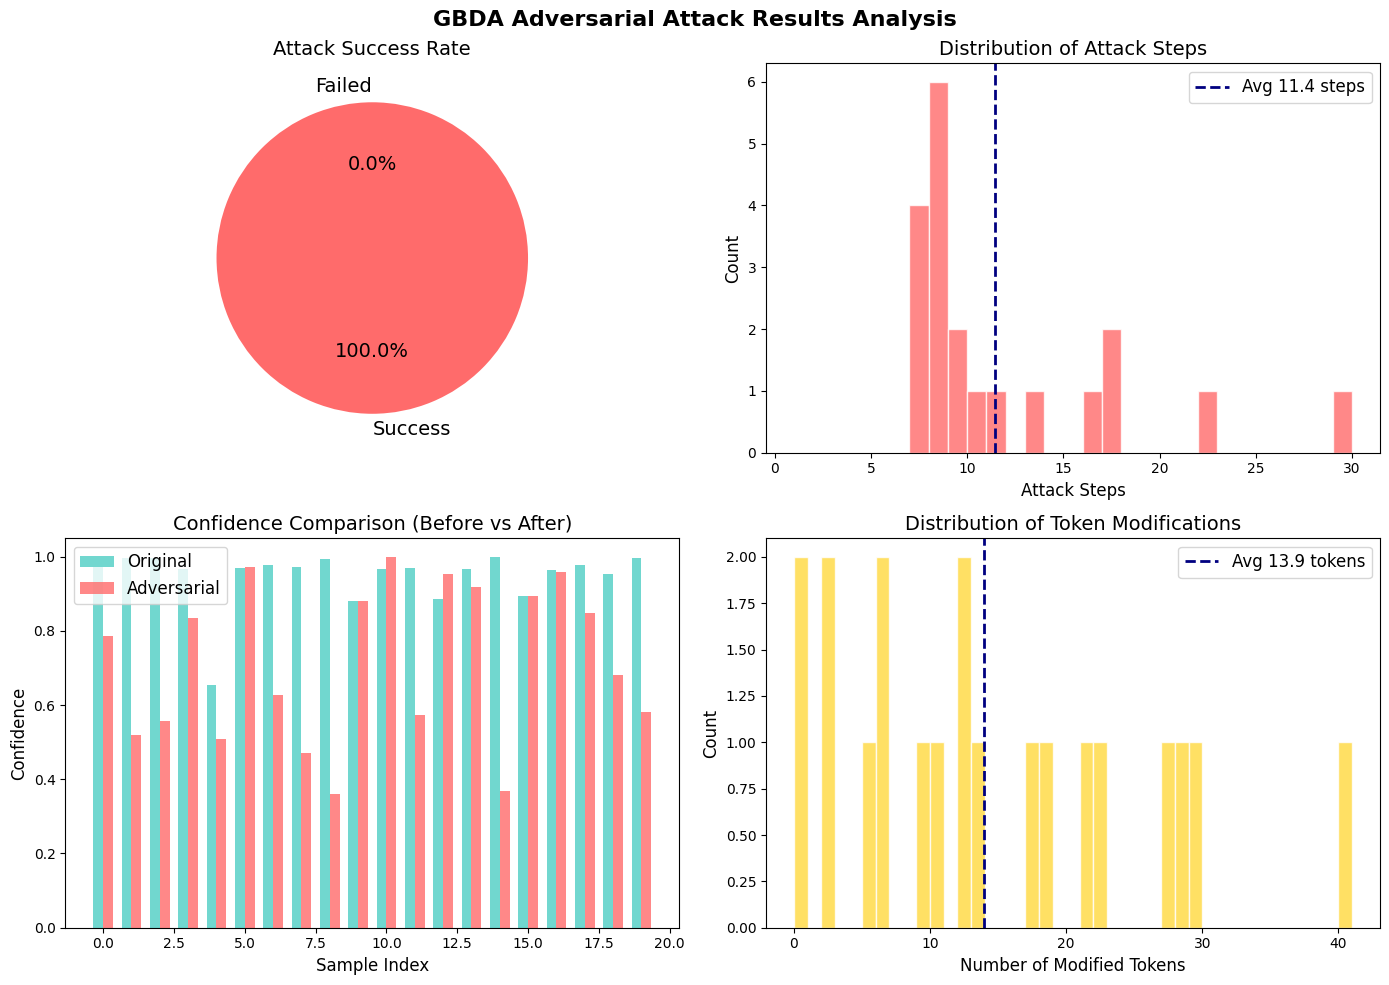

In [19]:
# 可视化
if len(results) == 0:
    print('没有攻击结果，跳过可视化！')
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('GBDA Adversarial Attack Results Analysis', fontsize=16, fontweight='bold')

    # 1. 攻击成功率
    ax1 = axes[0, 0]
    labels_pie = ['Success', 'Failed']
    sizes = [success_count, total - success_count]
    colors = ['#ff6b6b', '#4ecdc4']
    ax1.pie(sizes, labels=labels_pie, colors=colors, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 14})
    ax1.set_title('Attack Success Rate', fontsize=14)

    # 2. 成功步数分布
    ax2 = axes[0, 1]
    if success_results:
        steps = [r['steps'] for r in success_results]
        ax2.hist(steps, bins=range(1, max(steps) + 2), color='#ff6b6b', edgecolor='white', alpha=0.8)
        ax2.axvline(avg_steps, color='navy', linestyle='--', linewidth=2, label=f'Avg {avg_steps:.1f} steps')
        ax2.legend(fontsize=12)
    ax2.set_xlabel('Attack Steps', fontsize=12)
    ax2.set_ylabel('Count', fontsize=12)
    ax2.set_title('Distribution of Attack Steps', fontsize=14)

    # 3. 置信度变化
    ax3 = axes[1, 0]
    if success_results:
        orig_confs = [r['orig_confidence'] for r in success_results]
        adv_confs = [r['adv_confidence'] for r in success_results]
        x = range(len(orig_confs))
        width = 0.35
        ax3.bar([i - width/2 for i in x], orig_confs, width, label='Original', color='#4ecdc4', alpha=0.8)
        ax3.bar([i + width/2 for i in x], adv_confs, width, label='Adversarial', color='#ff6b6b', alpha=0.8)
        ax3.legend(fontsize=12)
    ax3.set_xlabel('Sample Index', fontsize=12)
    ax3.set_ylabel('Confidence', fontsize=12)
    ax3.set_title('Confidence Comparison (Before vs After)', fontsize=14)

    # 4. Token 修改数量
    ax4 = axes[1, 1]
    if token_changes:
        ax4.hist(token_changes, bins=range(0, max(token_changes) + 2), color='#ffd93d', edgecolor='white', alpha=0.8)
        ax4.axvline(avg_changes, color='navy', linestyle='--', linewidth=2, label=f'Avg {avg_changes:.1f} tokens')
        ax4.legend(fontsize=12)
    ax4.set_xlabel('Number of Modified Tokens', fontsize=12)
    ax4.set_ylabel('Count', fontsize=12)
    ax4.set_title('Distribution of Token Modifications', fontsize=14)

    plt.tight_layout()
    plt.savefig('gbda_attack_results.png', dpi=150, bbox_inches='tight')
    plt.show()

## 8. 攻击案例详解

In [21]:
# 展示攻击详细案例
if len(results) == 0:
    print('没有攻击结果，跳过案例展示！')
else:
    print('\n' + '=' * 70)
    print('                    攻击案例详解')
    print('=' * 70)

    for i, r in enumerate(success_results[:5]):
        print(f'\n--- 案例 {i+1} ---')
        print(f'真实标签:   {LABEL_NAMES[r["true_label"]]}')
        print(f'原始预测:   {LABEL_NAMES[r["original_pred"]]} (置信度: {r["orig_confidence"]:.3f})')
        print(f'对抗预测:   {LABEL_NAMES[r["adversarial_pred"]]} (置信度: {r["adv_confidence"]:.3f})')
        print(f'攻击步数:   {r["steps"]}')
        print(f'最终损失:   {r.get("final_loss", "N/A")}')
        print(f'\n原文:')
        print(f'  {r["original_text"][:200]}')
        print(f'\n对抗文本:')
        print(f'  {r["adversarial_text"][:200]}')
        
        # 标记修改的 token
        orig_ids = r['original_ids'].tolist()
        adv_ids = r['adversarial_ids'].tolist()
        changes = []
        for j, (a, b) in enumerate(zip(orig_ids, adv_ids)):
            if a != b:
                orig_word = tokenizer.idx2word.get(a, '<UNK>')
                adv_word = tokenizer.idx2word.get(b, '<UNK>')
                changes.append(f'  位置 {j}: "{orig_word}" -> "{adv_word}"')
        print(f'\nToken 修改 ({len(changes)} 处):')
        for c in changes:
            print(c)
        print('-' * 70)


                    攻击案例详解

--- 案例 1 ---
真实标签:   Business
原始预测:   Business (置信度: 0.971)
对抗预测:   World (置信度: 0.785)
攻击步数:   8
最终损失:   -11.974117279052734

原文:
  Fears for T N pension after talks Unions representing workers at Turner   Newall say they are 'disappointed' after talks with stricken parent firm Federal Mogul.

对抗文本:
  survive fears for t n pension after songs unions representing workers at turner <UNK> say they are disappointed after talks with stricken parent firm federal mogul

Token 修改 (2 处):
  位置 0: "<CLS>" -> "survive"
  位置 7: "talks" -> "songs"
----------------------------------------------------------------------

--- 案例 2 ---
真实标签:   Sci/Tech
原始预测:   Sci/Tech (置信度: 0.996)
对抗预测:   Business (置信度: 0.519)
攻击步数:   17
最终损失:   -11.569208145141602

原文:
  The Race is On: Second Private Team Sets Launch Date for Human Spaceflight (SPACE.com) SPACE.com - TORONTO, Canada -- A second\team of rocketeers competing for the  #36;10 million Ansari X Prize, a co

对抗文本:
  causing salar

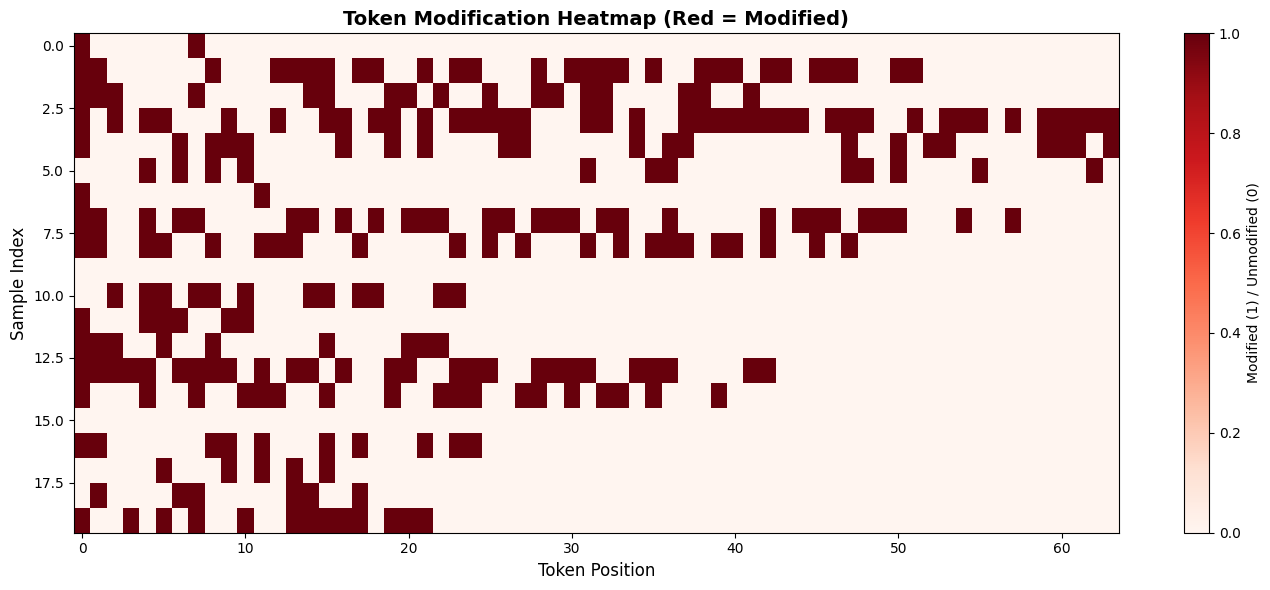

In [22]:
# Token 修改位置热力图
if len(results) == 0 or not success_results:
    print('没有攻击结果或无成功案例，跳过热力图！')
else:
    max_len = max(len(r['original_ids']) for r in success_results)
    heatmap = np.zeros((len(success_results), max_len))
    
    for i, r in enumerate(success_results):
        orig = r['original_ids'].tolist()
        adv = r['adversarial_ids'].tolist()
        for j in range(len(orig)):
            if orig[j] != adv[j]:
                heatmap[i, j] = 1
    
    fig, ax = plt.subplots(figsize=(14, 6))
    im = ax.imshow(heatmap, cmap='Reds', aspect='auto', interpolation='nearest')
    ax.set_xlabel('Token Position', fontsize=12)
    ax.set_ylabel('Sample Index', fontsize=12)
    ax.set_title('Token Modification Heatmap (Red = Modified)', fontsize=14, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Modified (1) / Unmodified (0)')
    plt.tight_layout()
    plt.savefig('gbda_token_modification_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

## 9. GBDA 优化过程可视化（单样本分析）

选取第一个成功样本，展示 GBDA 优化过程中的损失变化和温度退火曲线。

对第一个样本进行 GBDA 优化过程跟踪...


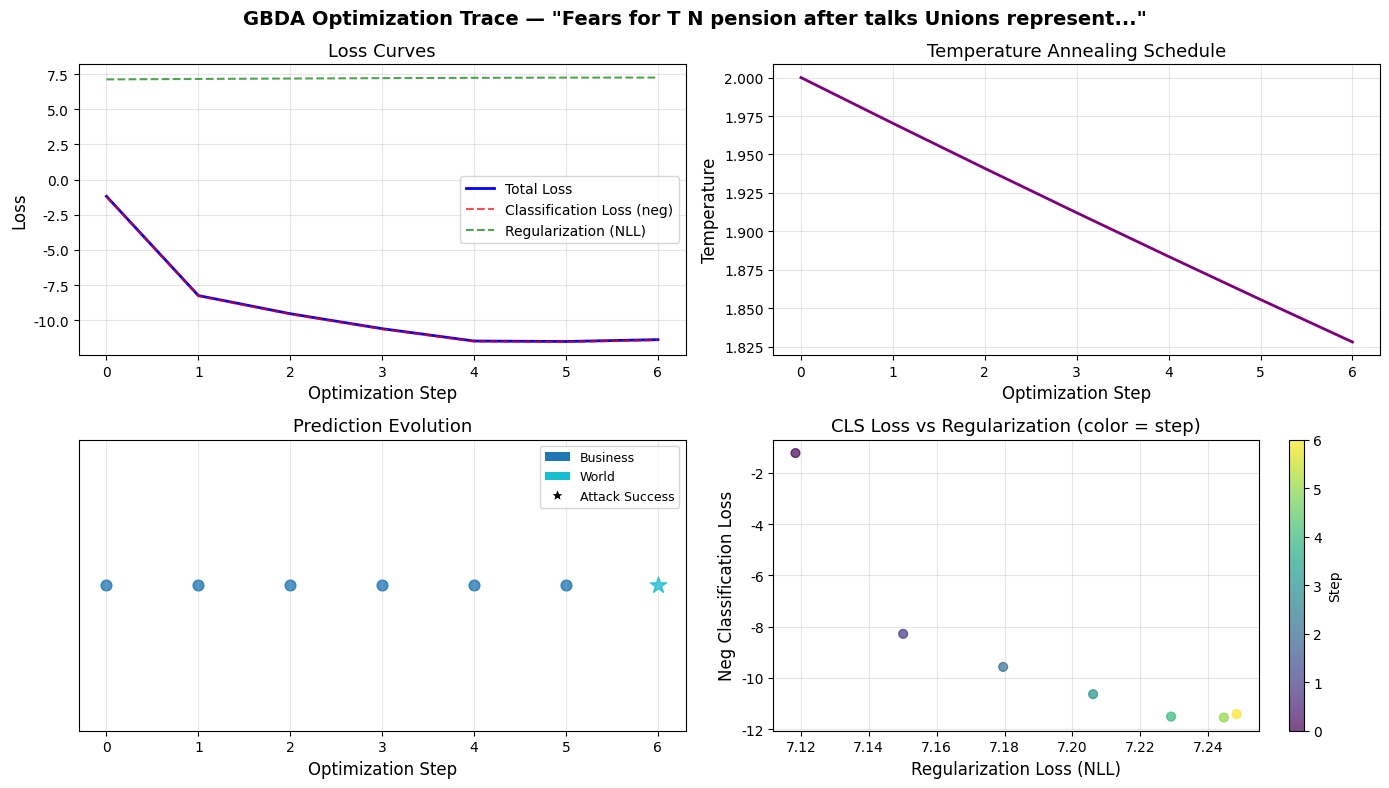

✓ 攻击在第 6 步成功！


In [23]:
# GBDA 优化过程跟踪（对单个样本详细分析）
def trace_gbda_attack(attacker, text, true_label):
    """跟踪 GBDA 攻击的详细优化过程"""
    input_ids = torch.tensor(
        attacker.tokenizer.encode(text), dtype=torch.long
    ).unsqueeze(0).to(device)
    
    seq_len = input_ids.size(1)
    vocab_size = attacker.tokenizer.vocab_size
    
    # 初始化 θ（与攻击器相同的初始化方式）
    theta = torch.zeros(1, seq_len, vocab_size, device=device)
    for i in range(seq_len):
        tid = input_ids[0, i].item()
        if tid != attacker.tokenizer.PAD_IDX:
            theta[0, i, tid] = 5.0
    theta = theta + torch.randn_like(theta) * 0.01
    theta.requires_grad_(True)
    
    orig_ids_flat = input_ids.squeeze(0)
    optimizer = torch.optim.Adam([theta], lr=attacker.lr)
    
    label_tensor = torch.tensor([true_label], device=device)
    
    # 记录优化轨迹
    history = {
        'step': [], 'temp': [], 'cls_loss': [], 'reg_loss': [],
        'total_loss': [], 'pred': [], 'success': []
    }
    
    with torch.no_grad():
        orig_logits = attacker.model(input_ids)
    
    for step in range(attacker.max_steps):
        temp = attacker._get_temperature(step)
        optimizer.zero_grad()
        
        # Gumbel-Softmax forward
        adv_sample = F.gumbel_softmax(theta, tau=temp, hard=False, dim=-1)
        adv_emb = adv_sample @ attacker.model.embedding.token_emb.weight
        adv_emb = adv_emb * attacker.model.embedding.embed_scale
        positions = torch.arange(seq_len, device=device).unsqueeze(0)
        adv_emb = adv_emb + attacker.model.embedding.pos_emb(positions)
        
        padding_mask = (input_ids == 0)
        logits = attacker.model.forward_from_embeddings(adv_emb, padding_mask=padding_mask)
        
        # 损失计算
        cls_loss = -F.cross_entropy(logits, label_tensor)
        adv_dist = F.softmax(theta / temp, dim=-1).squeeze(0)
        reg_loss = attacker._regularization_loss(adv_dist, orig_ids_flat)
        loss = cls_loss + attacker.reg_lambda * reg_loss
        
        loss.backward()
        optimizer.step()
        
        # 评估
        with torch.no_grad():
            hard_ids = theta.argmax(dim=-1)
            hard_logits = attacker.model(hard_ids)
            pred = hard_logits.argmax(dim=1).item()
            success = (pred != true_label)
        
        history['step'].append(step)
        history['temp'].append(temp)
        history['cls_loss'].append(cls_loss.item())
        history['reg_loss'].append(reg_loss.item())
        history['total_loss'].append(loss.item())
        history['pred'].append(pred)
        history['success'].append(success)
        
        if success:
            break
    
    return history


# 对第一个样本做详细跟踪
if len(correct_samples) > 0:
    print('对第一个样本进行 GBDA 优化过程跟踪...')
    sample = correct_samples[0]
    history = trace_gbda_attack(attacker, sample['text'], sample['label'])
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(f'GBDA Optimization Trace — "{sample["text"][:50]}..."', fontsize=14, fontweight='bold')
    
    steps = history['step']
    
    # 1. 损失曲线
    ax1 = axes[0, 0]
    ax1.plot(steps, history['total_loss'], 'b-', label='Total Loss', linewidth=2)
    ax1.plot(steps, history['cls_loss'], 'r--', label='Classification Loss (neg)', linewidth=1.5, alpha=0.7)
    ax1.plot(steps, history['reg_loss'], 'g--', label='Regularization (NLL)', linewidth=1.5, alpha=0.7)
    ax1.set_xlabel('Optimization Step', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_title('Loss Curves', fontsize=13)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # 2. 温度退火
    ax2 = axes[0, 1]
    ax2.plot(steps, history['temp'], 'purple', linewidth=2)
    ax2.set_xlabel('Optimization Step', fontsize=12)
    ax2.set_ylabel('Temperature', fontsize=12)
    ax2.set_title('Temperature Annealing Schedule', fontsize=13)
    ax2.grid(True, alpha=0.3)
    
    # 3. 预测演化
    ax3 = axes[1, 0]
    pred_nums = [LABEL_NAMES[p] for p in history['pred']]
    unique_preds = list(dict.fromkeys(pred_nums))
    colors_map = plt.cm.tab10(np.linspace(0, 1, len(unique_preds)))
    pred_to_color = {p: colors_map[i] for i, p in enumerate(unique_preds)}
    
    for i, (step_val, pred_name, succ) in enumerate(zip(steps, pred_nums, history['success'])):
        marker = 'o' if not succ else '*'
        size = 60 if not succ else 150
        ax3.scatter(step_val, 0, c=[pred_to_color[pred_name]], marker=marker, s=size, alpha=0.8)
    
    ax3.set_xlabel('Optimization Step', fontsize=12)
    ax3.set_yticks([])
    ax3.set_title('Prediction Evolution', fontsize=13)
    ax3.grid(True, alpha=0.3)
    
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=c, label=p) for p, c in pred_to_color.items()]
    legend_elements.append(plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='black', markersize=10, label='Attack Success'))
    ax3.legend(handles=legend_elements, fontsize=9, loc='upper right')
    
    # 4. CLS vs REG 对比
    ax4 = axes[1, 1]
    scatter = ax4.scatter(history['reg_loss'], history['cls_loss'], c=range(len(steps)),
                cmap='viridis', s=40, alpha=0.7)
    ax4.set_xlabel('Regularization Loss (NLL)', fontsize=12)
    ax4.set_ylabel('Neg Classification Loss', fontsize=12)
    ax4.set_title('CLS Loss vs Regularization (color = step)', fontsize=13)
    ax4.grid(True, alpha=0.3)
    cbar = plt.colorbar(scatter, ax=ax4)
    cbar.set_label('Step')
    
    plt.tight_layout()
    plt.savefig('gbda_optimization_trace.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    if any(history['success']):
        success_step = steps[history['success'].index(True)]
        print(f'✓ 攻击在第 {success_step} 步成功！')
    else:
        print('✗ 攻击未成功，可尝试增大 reg_lambda 或增加步数。')
else:
    print('没有正确分类的样本，跳过追踪。')

## 10. 总结

本 Notebook 实现了完整的 GBDA 对抗攻击流程：

1. **数据集**: AG News — 4 类新闻文本分类
2. **模型**: 自定义文本 Transformer（4 层，4 头，128 维）
3. **攻击**: GBDA 基于梯度的分布攻击
   - 使用 **Gumbel-Softmax** 实现连续松弛的离散采样
   - 通过 **梯度下降（Adam）** 优化每个 token 位置的概率分布
   - **负对数似然正则化**（替代有问题的 KL(⋅∥one-hot)）控制对抗扰动强度
   - **温度退火**使优化过程从探索逐渐过渡到利用

### GBDA vs GCG 对比

| 特性 | GCG | GBDA |
|------|-----|------|
| 优化方式 | 离散坐标贪心搜索 | 连续梯度下降 |
| 梯度利用 | 一次梯度 → 多候选评估 | 每步一次标准反向传播 |
| 搜索空间 | 逐位置替换枚举 | 连续分布空间 |
| 正则化 | 无 | 负对数似然（控制扰动强度）|
| 效率 | 每步需评估多个候选 | 标准 SGD，更高效 |
| 可微性 | 不完全是 | 完全可微（端到端）|

### 关键观察
- GBDA 通过连续优化能高效找到对抗扰动
- 正则化系数 $\lambda$ 控制攻击强度与语义相似度的平衡
- 温度退火策略对攻击成功率和生成质量有重要影响
- **注意**: 不能直接用 $\text{KL}(P_\theta \parallel \text{one-hot}(y_{\text{orig}}))$，因为 one-hot 分布的 $\log(0) = -\infty$ 会导致 NaN 梯度。应使用负对数似然 $-\log P_\theta(y_{\text{orig}})$ 代替。